# Notebook 08 — Random Forest con catálogo de features

**Proyecto:** PFM MUCSI Deusto — Predicción de consumo eléctrico doméstico
**Fase:** 2 — Modelado y comparativa (primer modelo clásico)
**Fecha:** 2026-05-12

## Objetivo

Entrenar el primer modelo clásico —**Random Forest**— sobre el catálogo de features del Nb04
y compararlo con los baselines del Nb07.

## Decisiones de diseño (cerradas con la tutora y registradas en CLAUDE.md)

1. **Granularidad:** resampling a **15 min** (de ~800 k a ~53 k filas por hogar).
   Justificación: hace tratable el RF sin perder los horizontes 15/60/1440 min;
   el horizonte de 1 min ya está dominado por la persistencia y no se vuelve a evaluar.
2. **Features:** se recalculan sobre la frecuencia 15 min para mantener semántica
   (lags y rollings en pasos de 15 min). Familias idénticas al catálogo Nb04
   (temporales, binarias, cíclicas, lags, rolling) — 22 features.
3. **Dos estrategias de modelado en paralelo:**
   - **RF por hogar** (18 modelos × 3 horizontes): personalización máxima.
   - **RF global** (3 modelos) con `id_hogar` como feature categórica: transferabilidad.
4. **Hiperparámetros:** `n_estimators=100`, `max_depth=15`, `random_state=42`, `n_jobs=-1`.
5. **Split temporal y métricas:** idénticos al Nb07 (80/20 cronológico, RMSE/MAE/MAPE/R²).


## 1. Imports y configuración

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEMILLA = 42
np.random.seed(SEMILLA)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DIR_PROCESSED = RAIZ / "datos" / "processed"
DIR_METRICAS = RAIZ / "resultados" / "metricas"
DIR_FIGURAS = RAIZ / "resultados" / "figuras"
DIR_METRICAS.mkdir(parents=True, exist_ok=True)
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

import sklearn
print(f"sklearn {sklearn.__version__} | pandas {pd.__version__} | numpy {np.__version__}")
print(f"Ruta raíz: {RAIZ}")


sklearn 1.7.2 | pandas 2.2.3 | numpy 2.0.2
Ruta raíz: C:\Users\super\Desktop\PFM_MUCSI_Deusto


## 2. Configuración del experimento

In [2]:
# Hogares — definidos en 06_seleccion_hogares_final.csv
HOGARES_TRAIN = [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 20, 21]
HOGARES_VALIDACION_EXTERNA = [2, 13]

# Granularidad y horizontes
FRECUENCIA = "15min"
PASOS_POR_HORA = 4               # 60 / 15
PASOS_POR_DIA = 24 * PASOS_POR_HORA  # 96
PASOS_POR_SEMANA = 7 * PASOS_POR_DIA # 672

# Horizontes en MINUTOS (idénticos a Nb07 para comparar) — se descarta el de 1 min
HORIZONTES_MIN = [15, 60, 1440]
HORIZONTES_PASOS = [h // 15 for h in HORIZONTES_MIN]  # [1, 4, 96]

FRACCION_TEST = 0.20
UMBRAL_MAPE_W = 50.0

# Hiperparámetros Random Forest
RF_PARAMS = dict(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    random_state=SEMILLA,
    n_jobs=-1,
)

print(f"Frecuencia objetivo: {FRECUENCIA} | pasos/día = {PASOS_POR_DIA}")
print(f"Horizontes (min → pasos): {dict(zip(HORIZONTES_MIN, HORIZONTES_PASOS))}")
print(f"RF: {RF_PARAMS}")


Frecuencia objetivo: 15min | pasos/día = 96
Horizontes (min → pasos): {15: 1, 60: 4, 1440: 96}
RF: {'n_estimators': 100, 'max_depth': 15, 'min_samples_leaf': 5, 'random_state': 42, 'n_jobs': -1}


## 3. Funciones auxiliares

- `cargar_aggregate_resampleado`: lee el agregado limpio y lo lleva a 15 min.
- `construir_features`: genera las 22 features (temporales + cíclicas + lags + rolling) sobre la frecuencia objetivo.
- `preparar_xy_horizonte`: añade el target desplazado y limpia NaN.
- `evaluar`: RMSE, MAE, MAPE filtrado y R².

In [3]:
def cargar_aggregate_resampleado(id_hogar: int, frecuencia: str = FRECUENCIA) -> pd.Series:
    '''Devuelve la serie Aggregate con índice temporal a la frecuencia indicada.'''
    ruta_features = DIR_PROCESSED / f"house{id_hogar}_features.csv"
    ruta_limpio = DIR_PROCESSED / f"house{id_hogar}_1min_limpio.csv"
    ruta = ruta_features if ruta_features.exists() else ruta_limpio
    if not ruta.exists():
        raise FileNotFoundError(f"No se encuentra el fichero para House{id_hogar}")

    cabecera = pd.read_csv(ruta, nrows=0).columns
    col_tiempo = "timestamp" if "timestamp" in cabecera else "Time"
    df = pd.read_csv(ruta, usecols=[col_tiempo, "Aggregate"], parse_dates=[col_tiempo])
    df = df.rename(columns={col_tiempo: "fecha"}).set_index("fecha").sort_index()

    # Resampling con media (filas NaN de minuto se ignoran)
    return df["Aggregate"].resample(frecuencia).mean()


def construir_features(serie: pd.Series) -> pd.DataFrame:
    '''Construye 22 features sobre la frecuencia de la serie de entrada.

    Familias: 5 temporales + 1 binaria + 8 cíclicas + 4 lags + 4 rolling.
    Los pasos de lags y ventanas se expresan en *pasos de la frecuencia objetivo*.
    '''
    df = pd.DataFrame({"Aggregate": serie})
    idx = df.index

    # 1) Temporales (5)
    df["hora"] = idx.hour
    df["minuto"] = idx.minute
    df["dia_semana"] = idx.dayofweek
    df["dia_mes"] = idx.day
    df["mes"] = idx.month

    # 2) Binarias (1)
    df["es_finde"] = (idx.dayofweek >= 5).astype(int)

    # 3) Cíclicas (8) — codificación sin/cos para evitar discontinuidades
    df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
    df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)
    df["dia_semana_sin"] = np.sin(2 * np.pi * df["dia_semana"] / 7)
    df["dia_semana_cos"] = np.cos(2 * np.pi * df["dia_semana"] / 7)
    df["mes_sin"] = np.sin(2 * np.pi * df["mes"] / 12)
    df["mes_cos"] = np.cos(2 * np.pi * df["mes"] / 12)
    df["dia_anyo"] = idx.dayofyear
    df["dia_anyo_sin"] = np.sin(2 * np.pi * df["dia_anyo"] / 365)

    # 4) Lags (4) en pasos de FRECUENCIA — 15 min, 1 h, 1 día, 7 días
    df["lag_1"] = df["Aggregate"].shift(1)
    df["lag_1h"] = df["Aggregate"].shift(PASOS_POR_HORA)
    df["lag_1d"] = df["Aggregate"].shift(PASOS_POR_DIA)
    df["lag_7d"] = df["Aggregate"].shift(PASOS_POR_SEMANA)

    # 5) Rolling sobre la frecuencia (4) — 1 h, 6 h, 1 día (media + std)
    df["media_movil_1h"] = df["Aggregate"].shift(1).rolling(PASOS_POR_HORA).mean()
    df["media_movil_6h"] = df["Aggregate"].shift(1).rolling(6 * PASOS_POR_HORA).mean()
    df["media_movil_1d"] = df["Aggregate"].shift(1).rolling(PASOS_POR_DIA).mean()
    df["std_movil_1d"] = df["Aggregate"].shift(1).rolling(PASOS_POR_DIA).std()

    # dia_anyo es feature auxiliar para crear el seno; la mantenemos por interpretabilidad
    return df


def preparar_xy_horizonte(df_features: pd.DataFrame, pasos_horizonte: int):
    '''Genera (X, y) descartando las filas con NaN en cualquier feature o en el target.

    El target es Aggregate desplazado pasos_horizonte hacia atrás (queremos predecir t+h).
    '''
    df = df_features.copy()
    df["target"] = df["Aggregate"].shift(-pasos_horizonte)
    df = df.dropna(subset=["target"])  # descarta últimos h pasos sin target
    df = df.dropna()                   # descarta primeros pasos sin lags/rolling

    columnas_features = [c for c in df.columns if c not in ("Aggregate", "target")]
    X = df[columnas_features]
    y = df["target"]
    return X, y, columnas_features


def evaluar(y_true, y_pred, umbral_mape: float = UMBRAL_MAPE_W) -> dict:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mascara = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_t, y_p = y_true[mascara], y_pred[mascara]
    if len(y_t) == 0:
        return dict(rmse=np.nan, mae=np.nan, mape=np.nan, r2=np.nan, n=0)
    rmse = float(np.sqrt(mean_squared_error(y_t, y_p)))
    mae = float(mean_absolute_error(y_t, y_p))
    r2 = float(r2_score(y_t, y_p))
    m = y_t > umbral_mape
    mape = float(np.mean(np.abs((y_t[m] - y_p[m]) / y_t[m])) * 100) if m.sum() else np.nan
    return dict(rmse=rmse, mae=mae, mape=mape, r2=r2, n=int(len(y_t)))


print("Funciones cargadas.")


Funciones cargadas.


## 4. Carga y construcción de features para los 20 hogares

Se almacena en memoria una vez. Después se reutiliza para los dos bloques de modelado.

In [4]:
t0 = time.time()
hogares = HOGARES_TRAIN + HOGARES_VALIDACION_EXTERNA
features_por_hogar = {}

for id_h in hogares:
    serie = cargar_aggregate_resampleado(id_h)
    df_feat = construir_features(serie)
    features_por_hogar[id_h] = df_feat
    print(f"H{id_h:>2}: {len(df_feat):>6} filas | "
          f"{df_feat.index.min().date()} → {df_feat.index.max().date()} | "
          f"NaN Aggregate = {df_feat['Aggregate'].isna().mean()*100:.1f}%")

print(f"\nCarga + features completadas en {time.time() - t0:.1f} s")


H 1:  61340 filas | 2013-10-09 → 2015-07-10 | NaN Aggregate = 12.0%


H 3:  59007 filas | 2013-09-25 → 2015-06-02 | NaN Aggregate = 12.1%


H 4:  60863 filas | 2013-10-11 → 2015-07-07 | NaN Aggregate = 11.2%


H 5:  62241 filas | 2013-09-26 → 2015-07-06 | NaN Aggregate = 7.8%


H 6:  55428 filas | 2013-11-28 → 2015-06-28 | NaN Aggregate = 14.7%


...

H19:  45162 filas | 2014-03-06 → 2015-06-20 | NaN Aggregate = 5.7%


H20:  44187 filas | 2014-03-20 → 2015-06-23 | NaN Aggregate = 5.8%


H21:  47023 filas | 2014-03-07 → 2015-07-10 | NaN Aggregate = 9.0%


H 2:  59273 filas | 2013-09-17 → 2015-05-28 | NaN Aggregate = 23.5%


H13:  47856 filas | 2014-01-17 → 2015-05-31 | NaN Aggregate = 21.2%

Carga + features completadas en 79.4 s


## 5. Bloque A — Random Forest por hogar

Un modelo independiente por (hogar, horizonte). Mide la capacidad de personalización.

In [5]:
resultados_por_hogar = []
importancias_por_hogar = []  # se guarda solo el modelo de horizonte=15 min para no inflar el CSV

for id_h in hogares:
    df_feat = features_por_hogar[id_h]
    rol = "train" if id_h in HOGARES_TRAIN else "validacion_externa"

    for h_min, h_pasos in zip(HORIZONTES_MIN, HORIZONTES_PASOS):
        X, y, cols = preparar_xy_horizonte(df_feat, h_pasos)
        if len(X) < 1000:  # protección frente a hogares con muy pocos datos válidos
            print(f"H{id_h:>2} h={h_min:>4}: solo {len(X)} filas → omitido")
            continue

        # Split cronológico 80/20
        n = len(X)
        corte = int(n * (1 - FRACCION_TEST))
        X_tr, X_te = X.iloc[:corte], X.iloc[corte:]
        y_tr, y_te = y.iloc[:corte], y.iloc[corte:]

        t_ini = time.time()
        modelo = RandomForestRegressor(**RF_PARAMS).fit(X_tr, y_tr)
        y_pred = modelo.predict(X_te)
        metricas = evaluar(y_te.to_numpy(), y_pred)
        t_total = time.time() - t_ini

        resultados_por_hogar.append(dict(
            hogar=id_h, rol=rol, horizonte_min=h_min, estrategia="rf_por_hogar",
            **metricas, segundos=round(t_total, 1),
        ))
        if h_min == 15:
            importancias_por_hogar.append(dict(
                hogar=id_h, **dict(zip(cols, modelo.feature_importances_))
            ))
        print(f"H{id_h:>2} h={h_min:>4}: RMSE={metricas['rmse']:>7.1f} | "
              f"MAE={metricas['mae']:>6.1f} | R²={metricas['r2']:>5.2f} | "
              f"n_test={metricas['n']:>5} | {t_total:>4.1f}s")

tabla_por_hogar = pd.DataFrame(resultados_por_hogar)
df_importancias = pd.DataFrame(importancias_por_hogar).set_index("hogar")
print(f"\nBloque A finalizado. Total filas: {len(tabla_por_hogar)}")


H 1 h=  15: RMSE=  555.1 | MAE= 230.4 | R²= 0.25 | n_test= 9384 |  5.7s


H 1 h=  60: RMSE=  597.2 | MAE= 264.2 | R²= 0.13 | n_test= 9370 |  5.2s


H 1 h=1440: RMSE=  610.6 | MAE= 258.7 | R²= 0.10 | n_test= 9164 |  5.7s


H 3 h=  15: RMSE=  614.9 | MAE= 357.4 | R²= 0.25 | n_test= 8653 |  4.9s


H 3 h=  60: RMSE=  660.4 | MAE= 404.0 | R²= 0.14 | n_test= 8642 |  4.6s


...

H 2 h=  60: RMSE=  783.4 | MAE= 398.7 | R²= 0.18 | n_test= 7836 |  2.8s


H 2 h=1440: RMSE=  821.7 | MAE= 456.6 | R²= 0.09 | n_test= 7684 |  2.7s


H13 h=  15: RMSE=  639.8 | MAE= 340.9 | R²= 0.40 | n_test= 6147 |  2.1s


H13 h=  60: RMSE=  736.4 | MAE= 386.5 | R²= 0.21 | n_test= 6136 |  2.0s


H13 h=1440: RMSE=  787.3 | MAE= 422.2 | R²= 0.12 | n_test= 5949 |  1.9s

Bloque A finalizado. Total filas: 60


## 6. Bloque B — Random Forest global

Un único modelo entrenado con la concatenación de todos los hogares de entrenamiento,
añadiendo `id_hogar` como feature ordinal. Se evalúa en el test de cada hogar
(incluidos los de validación externa, aunque sus datos NO entran en el train).

In [6]:
def preparar_dataset_global(features_dict, hogares_train, h_pasos):
    '''Concatena los hogares train con la columna id_hogar. Devuelve X, y, splits_por_hogar.'''
    frames_tr, frames_te = [], []
    splits_te = {}
    for id_h in hogares_train:
        df_feat = features_dict[id_h].copy()
        df_feat["id_hogar"] = id_h
        X, y, cols = preparar_xy_horizonte(df_feat, h_pasos)
        corte = int(len(X) * (1 - FRACCION_TEST))
        frames_tr.append(pd.concat([X.iloc[:corte], y.iloc[:corte].rename("target")], axis=1))
        bloque_test = pd.concat([X.iloc[corte:], y.iloc[corte:].rename("target")], axis=1)
        frames_te.append(bloque_test)
        splits_te[id_h] = bloque_test
    train_df = pd.concat(frames_tr, ignore_index=False)
    test_df = pd.concat(frames_te, ignore_index=False)
    return train_df, test_df, splits_te, cols + ["id_hogar"]


resultados_global = []
importancia_global = {}

for h_min, h_pasos in zip(HORIZONTES_MIN, HORIZONTES_PASOS):
    print(f"\n=== Horizonte {h_min} min ===")
    train_df, _test_df, splits_te, cols_global = preparar_dataset_global(
        features_por_hogar, HOGARES_TRAIN, h_pasos
    )
    X_tr = train_df[cols_global]
    y_tr = train_df["target"]
    print(f"Train concatenado: {len(X_tr):>7} filas × {X_tr.shape[1]} features")

    t_ini = time.time()
    modelo_global = RandomForestRegressor(**RF_PARAMS).fit(X_tr, y_tr)
    print(f"Entrenamiento: {time.time() - t_ini:.1f} s")
    importancia_global[h_min] = dict(zip(cols_global, modelo_global.feature_importances_))

    # Evaluar en el test de cada hogar (train + validación externa)
    for id_h in hogares:
        df_feat = features_por_hogar[id_h].copy()
        df_feat["id_hogar"] = id_h
        X, y, _ = preparar_xy_horizonte(df_feat, h_pasos)
        if len(X) < 1000:
            continue
        corte = int(len(X) * (1 - FRACCION_TEST))
        X_te = X.iloc[corte:][cols_global]
        y_te = y.iloc[corte:]
        y_pred = modelo_global.predict(X_te)
        rol = "train" if id_h in HOGARES_TRAIN else "validacion_externa"
        metricas = evaluar(y_te.to_numpy(), y_pred)
        resultados_global.append(dict(
            hogar=id_h, rol=rol, horizonte_min=h_min, estrategia="rf_global",
            **metricas,
        ))

tabla_global = pd.DataFrame(resultados_global)
print(f"\nBloque B finalizado. Total filas: {len(tabla_global)}")



=== Horizonte 15 min ===


Train concatenado:  589293 filas × 24 features


Entrenamiento: 82.8 s



=== Horizonte 60 min ===


Train concatenado:  588680 filas × 24 features


Entrenamiento: 76.6 s



=== Horizonte 1440 min ===


Train concatenado:  577716 filas × 24 features


Entrenamiento: 77.5 s



Bloque B finalizado. Total filas: 60


## 7. Comparativa unificada con baseline (Nb07)

Concatenamos los tres bloques en una sola tabla. Esa tabla es la columna *"RF"* en la
comparativa final del PFM.

In [7]:
# Cargar baselines del Nb07 y filtrar horizontes coherentes
baseline = pd.read_csv(DIR_METRICAS / "07_baseline.csv")
baseline = baseline[baseline["horizonte_min"].isin(HORIZONTES_MIN)].copy()
baseline["estrategia"] = "baseline_" + baseline["modelo"]
baseline = baseline.drop(columns=["modelo"])

tabla_completa = pd.concat([
    baseline[["hogar", "rol", "horizonte_min", "estrategia", "rmse", "mae", "mape", "r2", "n"]],
    tabla_por_hogar[["hogar", "rol", "horizonte_min", "estrategia", "rmse", "mae", "mape", "r2", "n"]],
    tabla_global[["hogar", "rol", "horizonte_min", "estrategia", "rmse", "mae", "mape", "r2", "n"]],
], ignore_index=True)

print("Estrategias en la tabla:", sorted(tabla_completa["estrategia"].unique()))
print(f"Total filas: {len(tabla_completa)}")
tabla_completa.head(10)


Estrategias en la tabla: ['baseline_media_hora_dia', 'baseline_persistencia', 'rf_global', 'rf_por_hogar']
Total filas: 240


,hogar,rol,horizonte_min,estrategia,rmse,mae,mape,r2,n
0,1,train,15,baseline_persistencia,845.248374,242.212332,54.911339,-0.591859,143889
1,1,train,15,baseline_media_hora_dia,676.977065,356.974717,118.666633,-0.021982,144085
2,1,train,60,baseline_persistencia,889.302482,291.799071,72.881111,-0.776566,143373
3,1,train,60,baseline_media_hora_dia,677.029970,356.958269,118.681983,-0.022027,144040
4,1,train,1440,baseline_persistencia,870.871659,279.359905,74.295047,-0.763563,132314
5,1,train,1440,baseline_media_hora_dia,670.875770,353.980788,119.140330,-0.026449,142660
6,3,train,15,baseline_persistencia,852.235699,395.810301,58.025632,-0.052494,152820
7,3,train,15,baseline_media_hora_dia,774.920808,460.805796,90.756237,0.130024,152896
8,3,train,60,baseline_persistencia,1013.970988,503.262774,83.226751,-0.495466,152580
9,3,train,60,baseline_media_hora_dia,775.019766,460.858721,90.761833,0.130031,152851


In [8]:
resumen = (
    tabla_completa.groupby(["rol", "horizonte_min", "estrategia"])
    [["rmse", "mae", "mape", "r2"]]
    .mean().round(2)
)
print("=== Comparativa: media por rol, horizonte y estrategia ===")
print(resumen.to_string())


=== Comparativa: media por rol, horizonte y estrategia ===
                                                             rmse     mae    mape    r2
rol                horizonte_min estrategia                                            
train              15            baseline_media_hora_dia   604.15  341.58   89.01  0.04
                                 baseline_persistencia     669.17  255.63   53.72 -0.23
                                 rf_global                 424.66  226.08   50.74  0.32
                                 rf_por_hogar              422.41  232.61   53.95  0.31
                   60            baseline_media_hora_dia   604.17  341.60   89.02  0.04
                                 baseline_persistencia     763.00  322.62   72.94 -0.57
                                 rf_global                 459.14  258.68   61.23  0.22
                                 rf_por_hogar              460.66  267.82   65.26  0.20
                   1440          baseline_media_hora_dia   60

## 8. Visualizaciones

Tres figuras clave para la memoria:
- **08a:** comparativa RMSE entre baselines y RF (por horizonte).
- **08b:** importancia media de features en el RF global (horizonte 15 min).
- **08c:** mejora absoluta del RF por hogar respecto al mejor baseline (heatmap).

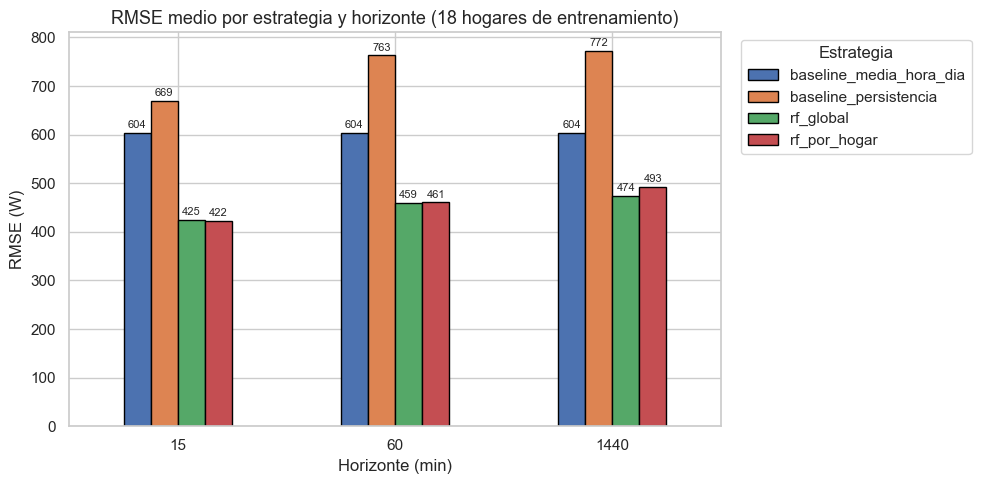

In [9]:
# Figura 08a — RMSE medio por estrategia y horizonte (solo train)
fig, ax = plt.subplots(figsize=(10, 5))
pivot = (
    resumen.loc["train", "rmse"]
    .unstack("estrategia")
)
pivot.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("RMSE medio por estrategia y horizonte (18 hogares de entrenamiento)")
ax.set_xlabel("Horizonte (min)")
ax.set_ylabel("RMSE (W)")
ax.legend(title="Estrategia", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(pivot.index, rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "08_rmse_estrategias_por_horizonte.png", dpi=120, bbox_inches="tight")
plt.show()


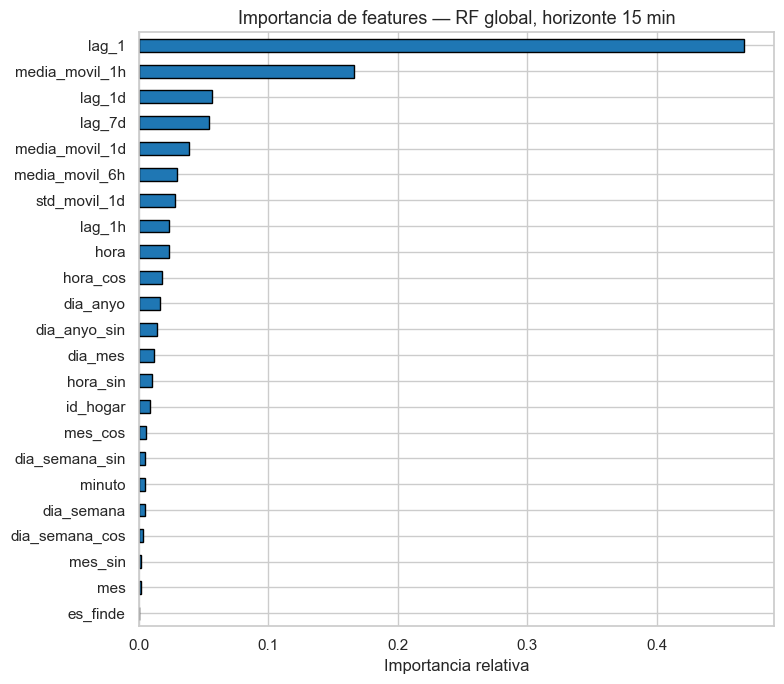

Top 5 features:
lag_1             0.467
media_movil_1h    0.166
lag_1d            0.057
lag_7d            0.054
media_movil_1d    0.039


In [10]:
# Figura 08b — Importancia de features del RF global (horizonte 15 min)
imp_15 = pd.Series(importancia_global[15]).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
imp_15.plot(kind="barh", ax=ax, color="#1f77b4", edgecolor="black")
ax.set_title("Importancia de features — RF global, horizonte 15 min")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "08_importancia_features_global_h15.png", dpi=120, bbox_inches="tight")
plt.show()

print("Top 5 features:")
print(imp_15.sort_values(ascending=False).head(5).round(3).to_string())


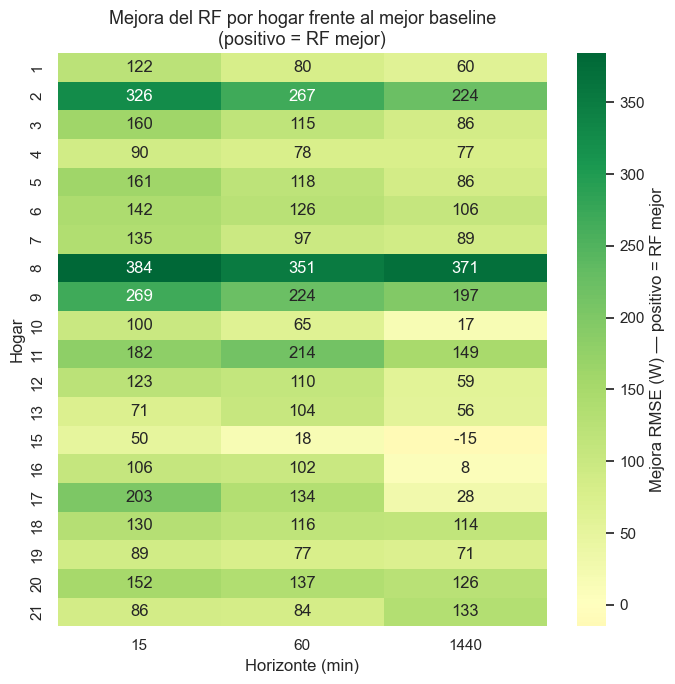

In [11]:
# Figura 08c — Mejora del RF por hogar vs mejor baseline
pivot_rmse = (
    tabla_completa
    .pivot_table(index=["hogar", "horizonte_min"], columns="estrategia", values="rmse")
    .reset_index()
)
pivot_rmse["mejor_baseline"] = pivot_rmse[["baseline_persistencia", "baseline_media_hora_dia"]].min(axis=1)
pivot_rmse["mejora_rf_hogar"] = pivot_rmse["mejor_baseline"] - pivot_rmse["rf_por_hogar"]

heat = pivot_rmse.pivot(index="hogar", columns="horizonte_min", values="mejora_rf_hogar")

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            cbar_kws={"label": "Mejora RMSE (W) — positivo = RF mejor"}, ax=ax)
ax.set_title("Mejora del RF por hogar frente al mejor baseline\n(positivo = RF mejor)")
ax.set_xlabel("Horizonte (min)")
ax.set_ylabel("Hogar")
plt.tight_layout()
plt.savefig(DIR_FIGURAS / "08_mejora_rf_vs_baseline.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Exportación de resultados

In [12]:
ruta_csv = DIR_METRICAS / "08_random_forest.csv"
tabla_completa.to_csv(ruta_csv, index=False)
print(f"Tabla completa guardada: {ruta_csv} ({len(tabla_completa)} filas)")

ruta_resumen = DIR_METRICAS / "08_random_forest_resumen.csv"
resumen.to_csv(ruta_resumen)
print(f"Resumen agregado guardado: {ruta_resumen}")

# Importancias del RF global (todos los horizontes)
df_imp_global = pd.DataFrame(importancia_global).round(4)
df_imp_global.index.name = "feature"
ruta_imp = DIR_METRICAS / "08_importancia_features_global.csv"
df_imp_global.to_csv(ruta_imp)
print(f"Importancia features RF global: {ruta_imp}")


Tabla completa guardada: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\08_random_forest.csv (240 filas)
Resumen agregado guardado: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\08_random_forest_resumen.csv
Importancia features RF global: C:\Users\super\Desktop\PFM_MUCSI_Deusto\resultados\metricas\08_importancia_features_global.csv


## 10. Conclusiones y siguientes pasos

Los hallazgos detallados se documentan en `resultados/08_hallazgos_random_forest.md` una vez ejecutado el notebook.
Esquema de conclusiones que se rellenará con los valores reales:

- **¿Bate el RF al mejor baseline en todos los horizontes?** (sí/no por horizonte).
- **¿Qué estrategia gana, por hogar o global?** y en qué casos.
- **Top 3 features dominantes** según importancia del RF global.
- **Hogares con peor comportamiento** — candidatos a inspección adicional.

### Siguiente paso — Notebook 09

Modelos de boosting (**XGBoost** y/o **LightGBM**) con el mismo protocolo (split, horizontes, métricas).
Si XGBoost supera al RF en RMSE y velocidad, se convierte en el modelo de referencia para la comparativa final
con redes neuronales (Nb 10/11).